In [1]:
import numpy as np
import pandas as pd
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

NumPy version: 1.26.4
Pandas version: 3.0.1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Set visual style
sns.set_theme(style="whitegrid", palette="muted")

In [7]:
# Load the dataset
# Note: Use the filename exactly as it appears in your folder
df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name=1)

In [9]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (5630, 20)


In [11]:
print("Columns in Dataset:", df.columns.tolist())

Columns in Dataset: ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


In [13]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [15]:
### Deep Data Cleaning & EDA

In [17]:
# Check missing values before
print("Missing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
 Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64


In [19]:
# Filling missing values
cols_to_fix = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
               'OrderAmountHikeFromlastYear', 'CouponUsed', 
               'OrderCount', 'DaySinceLastOrder']

In [21]:
for col in cols_to_fix:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after cleaning:", df.isnull().sum().sum())


Missing values after cleaning: 0


### Analyzing the Target Variable (Churn)

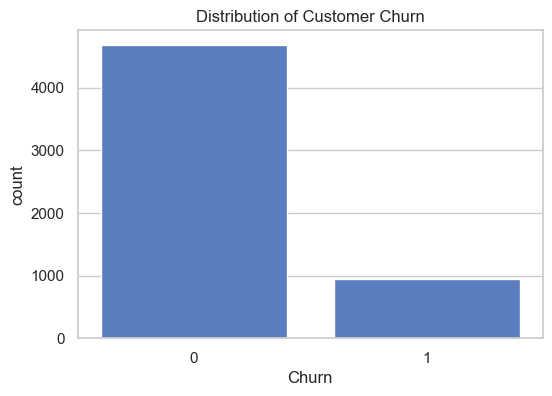

Churn Rate: 16.84%
Retention Rate: 83.16%


In [24]:
# Visualizing Churn Distribution

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Customer Churn')
plt.show()

churn_perc = df['Churn'].value_counts(normalize=True) * 100
print(f"Churn Rate: {churn_perc[1]:.2f}%")
print(f"Retention Rate: {churn_perc[0]:.2f}%")

In [79]:
# Calculate correlation only for numerical columns
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()

<Figure size 1200x800 with 0 Axes>

Text(0.5, 1.0, 'Feature Correlation Heatmap')

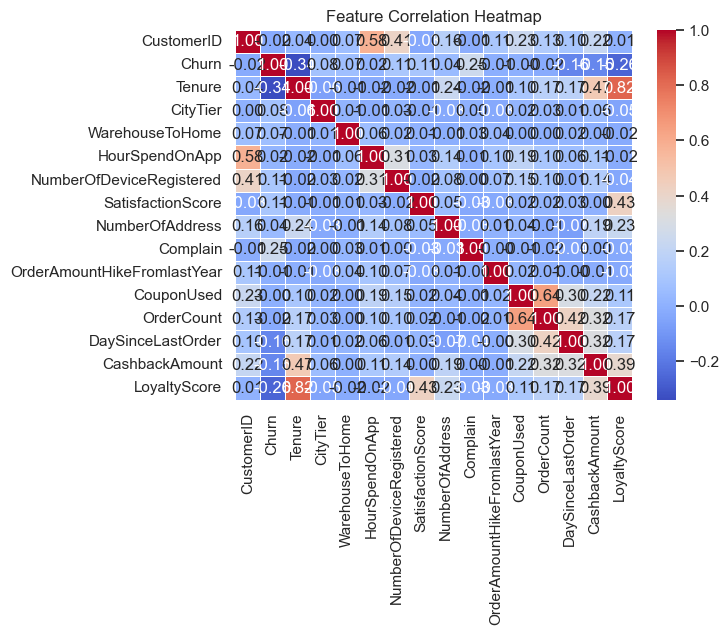

In [81]:
# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')

In [83]:
# SAVE the plot to your computer
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

### 2: Advanced Feature Engineering

In [27]:
# 1. Create Behavioral Features
# 'Tenure' is a strong predictor; let's create a 'LoyaltyScore'
df['LoyaltyScore'] = df['Tenure'] * df['SatisfactionScore']
df['LoyaltyScore']

0        8.0
1       27.0
2       27.0
3        0.0
4        0.0
        ... 
5625    10.0
5626    65.0
5627     4.0
5628    92.0
5629    24.0
Name: LoyaltyScore, Length: 5630, dtype: float64

In [29]:
# 2. Simplify categorical columns for better model performance
# Combining similar login devices
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace(['Mobile Phone'], 'Phone')
df['PreferredLoginDevice']

0          Phone
1          Phone
2          Phone
3          Phone
4          Phone
          ...   
5625    Computer
5626       Phone
5627       Phone
5628    Computer
5629       Phone
Name: PreferredLoginDevice, Length: 5630, dtype: str

In [31]:
# 3. One-Hot Encoding (Turning text into 0s and 1s)
# This is a MUST for Neural Networks
categorical_cols = df.select_dtypes(include=['object']).columns
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_final

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,50001,1,4.0,3,6.0,3.0,3,2,9,1,...,False,False,False,False,True,False,False,False,False,True
1,50002,1,9.0,1,8.0,3.0,4,3,7,1,...,False,True,True,False,False,True,False,False,False,True
2,50003,1,9.0,1,30.0,2.0,4,3,6,1,...,False,False,True,False,False,True,False,False,False,True
3,50004,1,0.0,3,15.0,2.0,4,5,8,0,...,False,False,True,False,True,False,False,False,False,True
4,50005,1,0.0,1,12.0,3.0,3,5,3,0,...,False,False,True,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,10.0,1,30.0,3.0,2,1,6,0,...,False,False,True,False,True,False,False,False,True,False
5626,55627,0,13.0,1,13.0,3.0,5,5,6,0,...,False,False,True,False,False,False,False,False,True,False
5627,55628,0,1.0,1,11.0,3.0,2,4,3,1,...,False,False,True,False,True,False,False,False,True,False
5628,55629,0,23.0,3,9.0,4.0,5,4,4,0,...,False,False,True,False,True,False,False,False,True,False


In [33]:
# 4. Drop columns that don't help the model (like ID)
df_final = df_final.drop('CustomerID', axis=1)

print(f"Original columns: {df.shape[1]}")
print(f"Columns after encoding: {df_final.shape[1]}")
df_final.head()

Original columns: 21
Columns after encoding: 30


,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,...,False,False,False,False,True,False,False,False,False,True
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,...,False,True,True,False,False,True,False,False,False,True
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,...,False,False,True,False,False,True,False,False,False,True
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,...,False,False,True,False,True,False,False,False,False,True
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,...,False,False,True,False,False,True,False,False,False,True


### 3: The Deep Learning Model (ANN)

In [36]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [38]:
# 1. Prepare Features and Target
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

In [39]:
# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
# 3. Scaling (Essential for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
# 4. Building the Artificial Neural Network (ANN)
model = Sequential([
    # Input Layer & First Hidden Layer
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(), 
    Dropout(0.3),         

    # Second Hidden Layer
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Output Layer (Sigmoid for binary classification: Churn or Not)
    Dense(1, activation='sigmoid')
]) # This closes the list and the Sequential function

In [42]:
# 5. Compile the Model
# We use Recall as a metric because catching someone who MIGHT churn is the priority.
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy', tf.keras.metrics.Recall()])

In [43]:
# 6. Train the Model
print("Training Neural Network...")
history = model.fit(X_train_scaled, y_train, 
                    epochs=50, 
                    batch_size=32, 
                    validation_split=0.2, 
                    verbose=1)

Training Neural Network...
Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6550 - loss: 0.6459 - recall: 0.6128 - val_accuracy: 0.8568 - val_loss: 0.4467 - val_recall: 0.4146
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8052 - loss: 0.4456 - recall: 0.5303 - val_accuracy: 0.8690 - val_loss: 0.3513 - val_recall: 0.4268
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8537 - loss: 0.3565 - recall: 0.5017 - val_accuracy: 0.8868 - val_loss: 0.3166 - val_recall: 0.4817
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8665 - loss: 0.3275 - recall: 0.4646 - val_accuracy: 0.8790 - val_loss: 0.3051 - val_recall: 0.4695
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8801 - loss: 0.3026 - recall: 0.5067 - val_accuracy: 0.8868 - val_loss: 0.2978 - val_recall: 0.4939
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8795 - loss: 0.2913 - recall: 0.5034 - val_accuracy: 0.8890 - val_loss: 0.292

In [44]:
# 7. Evaluate
loss, accuracy, recall = model.evaluate(X_test_scaled, y_test)
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")
print(f"Final Test Recall: {recall*100:.2f}%")

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9343 - loss: 0.1701 - recall: 0.6842

Final Test Accuracy: 93.43%
Final Test Recall: 68.42%


In [45]:
!pip install shap

  Using cached numpy-2.4.2-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.2-cp312-cp312-win_amd64.whl (12.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.2 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.1 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.33.5 which is incompatible.


In [46]:
import shap

In [47]:
# 1. Initialize SHAP for the Neural Network
# Since ANN is a 'black box', we use KernelExplainer or DeepExplainer.
# We'll use a small subset (background data) to speed up calculation.
background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)]
explainer = shap.KernelExplainer(model.predict, background)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [49]:
# 2. Calculate SHAP values for the test set
# (Using 50 samples for quick execution in the notebook)
shap_values = explainer.shap_values(X_test_scaled[:50])

  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━

In [50]:
import numpy as np
import shap

# 1. Calculate SHAP values (Ensure this matches the slice of X_test_scaled)
# We use .predict for Keras models
# Note: This step takes a few minutes because KernelExplainer is computationally heavy.
shap_values = explainer.shap_values(X_test_scaled[:50])

  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
6582/6582 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━

In [51]:
# 2. SME Fix: Handle Dimension Mismatch
# We convert to a numpy array and squeeze out the single-class dimension (N, features, 1) -> (N, features)
shap_values_plot = np.squeeze(shap_values)

In [52]:
# 3. Final Check: SHAP values shape must match (50, features)
print(f"SHAP Values Shape: {shap_values_plot.shape}")
print(f"Data Matrix Shape: {X_test_scaled[:50].shape}")

SHAP Values Shape: (50, 29)
Data Matrix Shape: (50, 29)


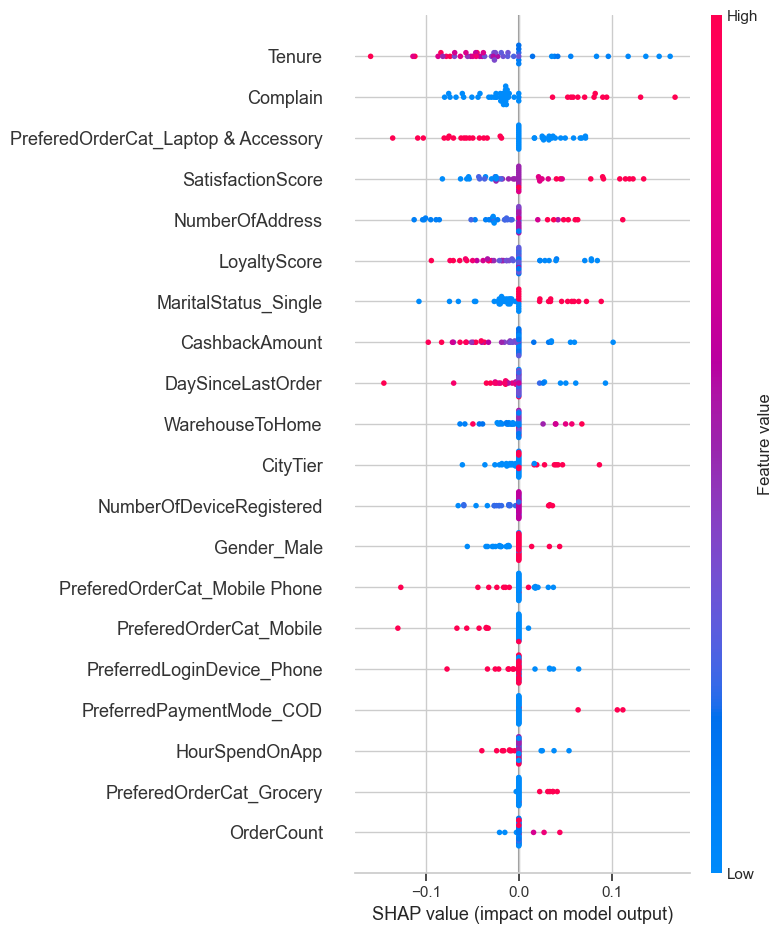

In [53]:
# 4. Generate the Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_plot, X_test_scaled[:50], feature_names=X.columns)

In [85]:
# SAVE the plot to your computer
plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [54]:
# Save the model for future use or deployment
model.save('ecommerce_churn_model.keras')

In [55]:
# Save the scaler as well (essential for processing new data)
import joblib
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved successfully. The project is production-ready!")

Model and Scaler saved successfully. The project is production-ready!
